## Cancer type sunburst: tissue site, origin, subtype and plate condition

Nested rings (inner to outer, each named in the gap just outside it, and wrapped in a thin band in the site colour that names each tissue site) describing the atlas cell lines from `../pccma_cell_line_metadata.csv`, each ring subdividing
the wedges of the ring inside it and sized by the number of cell lines:

1. **Tissue site** (site colours from the repo-level `themes.R`; sites come from `plotting_helpers/cancer_type_categories.yaml`)
2. **Origin** of the cell line: primary (lighter shade of the site colour), metastasis (darker shade)
3. **Subtype**, in the colour of the origin wedge it belongs to (unknown where not annotated)
4. **Plate condition**, one colour per condition

Cell lines with no annotation for origin or subtype are labelled unknown; unknown origin is shown as a very pale tint of the site colour. `U2-OS` was run under several plate
conditions: it is counted once overall, and its share of the outer ring is split across its plate conditions.

In [1]:
suppressPackageStartupMessages(library(stringr))

source(file.path("..", "plotting_helpers", "cell_line_figure_utils.R"))

metadata_file <- file.path("..", "pccma_cell_line_metadata.csv")
categories_file <- file.path("..", "plotting_helpers", "cancer_type_categories.yaml")
output_dir <- "figures"
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

### Prepare the nested counts

Each cell line contributes a total weight of 1, divided across its plate-condition rows.

In [2]:
atlas <- prepare_cancer_type_data(metadata_file, categories_file)
site_order <- atlas$site_counts$site
plate_levels <- names(plate_colors)

rows <- read_csv(metadata_file, col_types = cols(.default = col_character())) %>%
  left_join(atlas$cell_lines %>% select(cell_line_key, site), by = "cell_line_key") %>%
  group_by(cell_line_key) %>%
  mutate(weight = 1 / n()) %>%
  ungroup() %>%
  transmute(cell_line_key,
            site = factor(site, site_order),
            origin = factor(coalesce(origin, "Unknown"), origin_levels),
            subtype = coalesce(subtype, "Unknown"),
            plate = factor(plate_conditions, plate_levels),
            weight)
stopifnot("unknown plate condition" = !anyNA(rows$plate))
stopifnot("weights must add up to one per cell line" = abs(sum(rows$weight) - n_distinct(rows$cell_line_key)) < 1e-9)
n_cell_lines <- n_distinct(rows$cell_line_key)

# order subtypes within each site and origin by size, with "Unknown" last
subtype_rank <- rows %>%
  group_by(site, origin, subtype) %>%
  summarise(w = sum(weight), .groups = "drop") %>%
  group_by(site, origin) %>%
  arrange(subtype == "Unknown", desc(w), subtype, .by_group = TRUE) %>%
  mutate(subtype_rank = row_number()) %>%
  ungroup() %>%
  select(site, origin, subtype, subtype_rank)
rows <- left_join(rows, subtype_rank, by = c("site", "origin", "subtype"))

# one table per ring: a wedge for each combination of the columns up to that ring
group_keys <- list("site", c("site", "origin"), c("site", "origin", "subtype", "subtype_rank"),
                   c("site", "origin", "subtype", "subtype_rank", "plate"))
sort_keys <- list("site", c("site", "origin"), c("site", "origin", "subtype_rank"),
                  c("site", "origin", "subtype_rank", "plate"))
site_gap <- 2.6   # degrees of white space between tissue sites
ring_table <- function(k) {
  rows %>%
    group_by(across(all_of(group_keys[[k]]))) %>%
    summarise(w = sum(weight), .groups = "drop") %>%
    arrange(across(all_of(sort_keys[[k]]))) %>%
    mutate(ring = k, span = 360 - site_gap * length(site_order),
           start = (as.integer(site) - 0.5) * site_gap + span * (cumsum(w) - w) / n_cell_lines,
           end = start + span * w / n_cell_lines, mid = (start + end) / 2)
}
rings <- lapply(1:4, ring_table)
cat("cell lines:", n_cell_lines, "| wedges per ring:", paste(sapply(rings, nrow), collapse = ", "), "\n")
print(as.data.frame(rings[[3]] %>% filter(subtype != "Unknown") %>% select(site, origin, subtype, w)), row.names = FALSE)

cell lines: 56 | wedges per ring: 8, 16, 25, 39 


                   site     origin            subtype w
          Adrenal gland    Primary           MYCN_amp 3
          Adrenal gland Metastasis           MYCN_amp 3
          Adrenal gland Metastasis            MYCN_wt 3
                   Bone    Primary            EWS_FLI 2
                   Bone    Primary            EWS_ERG 1
                   Bone Metastasis            EWS_FLI 3
                   Bone Metastasis            EWS_ERG 1
 Central nervous system    Primary            non_MYC 2
 Central nervous system    Unknown MYCN/ID2 amplified 1
            Soft tissue Metastasis         PAX3_FOXO1 1


### Colours

Ring 2 shades each site colour by origin (`origin_shade()` in `themes.R`), ring 3 keeps the colour of the origin wedge each
subtype belongs to, and ring 4 gives each plate condition its own colour (`plate_colors` in `themes.R`), independent of the
site.

In [3]:
rings[[1]] <- rings[[1]] %>% mutate(base = unname(site_colors[as.character(site)]), fill = base)
rings[[2]] <- rings[[2]] %>%
  mutate(base = unname(site_colors[as.character(site)]), fill = origin_shade(base, as.character(origin)))
rings[[3]] <- rings[[3]] %>%
  mutate(base = unname(site_colors[as.character(site)]),
         origin_fill = origin_shade(base, as.character(origin)),
         fill = origin_fill)   # a subtype wedge keeps the colour of the origin wedge it sits in
rings[[4]] <- rings[[4]] %>%
  mutate(base = unname(site_colors[as.character(site)]), fill = unname(plate_colors[as.character(plate)]))

# ring radii (plot units)
ring_gap <- 0.5                                  # plot units between rings; also holds the curved ring names
ring_widths <- c(1.0, 1.1, 1.2, 0.8)
r_start <- 1.9                                   # inner radius of ring 1 (the hole is ring_gap smaller)
r_inner <- r_start + c(0, cumsum(ring_widths + ring_gap))[1:4]
r_edges <- lapply(1:4, function(k) c(r_inner[k], r_inner[k] + ring_widths[k]))
wedges <- bind_rows(lapply(1:4, function(k) rings[[k]] %>% mutate(r0 = r_edges[[k]][1], r1 = r_edges[[k]][2]))) %>%
  mutate(id = row_number())
r_out <- max(wedges$r1)

# polygon outline of each wedge
poly_data <- bind_rows(lapply(seq_len(nrow(wedges)), function(i) {
  w <- wedges[i, ]
  a <- seq(w$start, w$end, length.out = max(2, ceiling((w$end - w$start) / 2)) + 1) * pi / 180
  tibble(id = w$id, fill = w$fill,
         x = c(w$r1 * sin(a), w$r0 * sin(rev(a))), y = c(w$r1 * cos(a), w$r0 * cos(rev(a))))
}))

### Labels, site band and key

Every origin and subtype wedge is named along its radius (subtypes may be unknown), each ring is named in a curved label
just outside it, and a thin band in the site colour around the outside carries each tissue site's name with its cell line
total (sites too narrow for their name, such as ovary, are named just outside the band). The key on the right shows the
plate condition colours.

In [4]:
text_on <- function(fill) ifelse(colSums(col2rgb(fill) * c(0.299, 0.587, 0.114)) / 255 < 0.55, "white", "grey15")
radial <- function(df) {
  df %>%
    mutate(r = (r0 + r1) / 2, x = r * sin(mid * pi / 180), y = r * cos(mid * pi / 180),
           angle = { phi <- ((90 - mid + 180) %% 360) - 180; ifelse(abs(phi) > 90, phi + 180, phi) },
           colour = text_on(fill))
}
subtype_names <- c("MYCN/ID2 amplified" = "MYCN/ID2 amp")

origin_labels <- radial(wedges %>% filter(ring == 2) %>% mutate(label = as.character(origin)))
subtype_labels <- radial(wedges %>% filter(ring == 3) %>% mutate(label = recode(subtype, !!!subtype_names)))

# ---- text measurement (approximate Helvetica character widths in em) ----
upi <- 1.75   # plot units per inch: sets the text size relative to the rings
em_widths <- setNames(c(556, 556, 500, 556, 556, 278, 556, 556, 222, 222, 500, 222, 833, 556, 556, 556, 556, 333, 500, 278,
                        556, 500, 722, 500, 500, 500,
                        667, 667, 722, 722, 667, 611, 778, 722, 278, 500, 667, 556, 833, 722, 778, 667, 778, 722, 667, 611,
                        722, 667, 944, 667, 667, 611, 278, 333, 333, 584) / 1000,
                      c(letters, LETTERS, " ", "(", ")", "="))
char_em <- function(ch) { w <- unname(em_widths[ch]); w[is.na(w)] <- 0.556; w }   # digits and others: 0.556 em
em_units <- function(size_mm) size_mm * 2.845 / 72 * upi                           # one em in plot units
text_units <- function(label, size_mm, bold = FALSE) {                              # width of the longest line
  max(sapply(strsplit(label, "\n")[[1]], function(l) sum(char_em(strsplit(l, "")[[1]])))) *
    (if (bold) 1.06 else 1) * em_units(size_mm)
}

# text along a circle of radius r, centred on angle `mid` (degrees clockwise from 12 o'clock); in the bottom half
# the text runs against the clock so that it stays upright
curved_text <- function(label, r, mid = 0, size_mm = 3.9, bold = TRUE) {
  chars <- strsplit(label, "")[[1]]
  em <- em_units(size_mm)
  w <- char_em(chars) * (if (bold) 1.06 else 1) * em
  offset <- cumsum(w) - w / 2 - sum(w) / 2       # distance of each character's centre from the middle of the text
  flip <- cos(mid * pi / 180) < 0
  theta <- mid + (if (flip) -offset else offset) / r * 180 / pi
  r_base <- if (flip) r + 0.36 * em else r - 0.36 * em   # baseline radius, so capital letters are centred on r
  data.frame(char = chars, x = r_base * sin(theta * pi / 180), y = r_base * cos(theta * pi / 180),
             angle = if (flip) 180 - theta else -theta)
}

# ---- ring names: in the gap just outside each ring, centred on 12 o'clock ----
ring_label_size <- 4.9                           # text size (mm): larger than the site names, so the rings are easy to identify
ring_names <- c("Tissue site", "Origin", "Subtype", "Plate condition")
ring_label_chars <- bind_rows(lapply(1:4, function(k) curved_text(ring_names[k], r_edges[[k]][2] + ring_gap / 2, 0, ring_label_size)))

# ---- thin band in the site colour around the outside, carrying the tissue site names ----
band_width <- 0.46
band_r0 <- r_out + ring_gap
band_r1 <- band_r0 + band_width
band_r <- (band_r0 + band_r1) / 2
band_text_size <- 3.6
arc_polygon <- function(id, r0, r1, start, end, fill) {
  a <- seq(start, end, length.out = max(2, ceiling((end - start) / 2)) + 1) * pi / 180
  tibble(id = id, fill = fill, x = c(r1 * sin(a), r0 * sin(rev(a))), y = c(r1 * cos(a), r0 * cos(rev(a))))
}
sites <- wedges %>%
  filter(ring == 1) %>%
  mutate(label = paste0(str_remove(site, " lines$"), " (n=", round(w), ")"),   # "Normal reference lines" -> "Normal reference"
         text_w = sapply(label, text_units, size_mm = band_text_size, bold = TRUE),
         arc_len = (end - start) * pi / 180 * band_r,
         inside = text_w + 0.3 <= arc_len)
band_poly <- bind_rows(lapply(seq_len(nrow(sites)), function(i)
  arc_polygon(1000 + i, band_r0, band_r1, sites$start[i], sites$end[i], sites$base[i])))
band_chars <- bind_rows(lapply(which(sites$inside), function(i)
  curved_text(sites$label[i], band_r, sites$mid[i], band_text_size) %>% mutate(colour = text_on(sites$base[i]))))
# sites too narrow for their name: named just outside the band
site_labels <- sites %>%
  filter(!inside) %>%
  mutate(x = (band_r1 + 0.3) * sin(mid * pi / 180), y = (band_r1 + 0.3) * cos(mid * pi / 180),
         hjust = ifelse(x >= 0, 0, 1),
         colour = unname(site_text_colors[as.character(site)]))
out_ext <- site_labels$x + ifelse(site_labels$hjust == 0, 1, -1) *
  sapply(site_labels$label, text_units, size_mm = 3.9, bold = TRUE)

# ---- key on the right of the rings: the plate condition colours ----
key_size <- 3.8        # text size (mm)
key_swatch <- 0.3      # swatches are squares
key_pad <- 0.18        # plot units of padding around each key row
key_lineheight <- 0.85 # spacing between the lines of a multi-line label
line_h <- em_units(key_size)
key_labels <- str_replace(names(plate_colors), " w/ double PFA fixation", "\nw/ double PFA\nfixation")
item_h <- key_pad + line_h * (key_lineheight * str_count(key_labels, "\n") + 1)
title_h <- key_pad + line_h
key_h <- title_h + sum(item_h)
key_titles <- data.frame(y = key_h / 2 - title_h / 2, label = "Plate condition")
key_items <- data.frame(y = key_h / 2 - title_h - cumsum(item_h) + item_h / 2, label = key_labels, fill = unname(plate_colors))

key_x <- max(c(band_r1, out_ext[site_labels$hjust == 0])) + 0.5
key_right <- key_x + max(text_units("Plate condition", key_size, bold = TRUE),
                         0.5 + sapply(key_labels, text_units, size_mm = key_size))

x_lim <- c(min(c(-band_r1, out_ext[site_labels$hjust == 1])) - 0.05, key_right + 0.05)
y_lim <- c(min(c(-band_r1, site_labels$y - 0.25)) - 0.05, max(c(band_r1, site_labels$y + 0.25)) + 0.05)
margin_pt <- 4
fig_width <- diff(x_lim) / upi + 2 * margin_pt / 72
fig_height <- diff(y_lim) / upi + 2 * margin_pt / 72

subtype labels: 25 of 25 wedges (15 unknown); site names inside the band: 7 of 8


figure size: 11.43 x 9.84 in


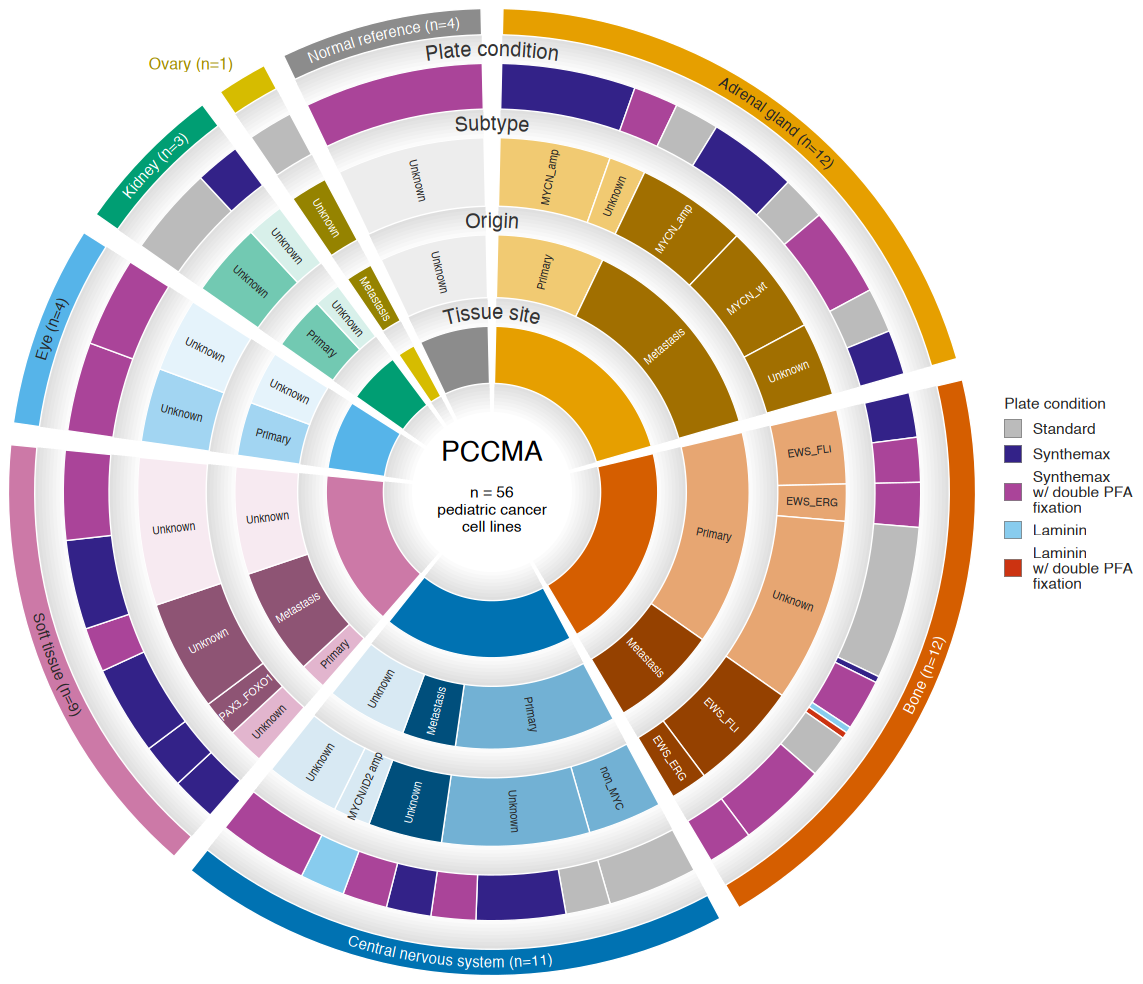

In [5]:
# ---- depth: looking straight down into a cylinder, with the light directly overhead ----
# The rings are terraces stepping down toward the centre, so each ring's inner wall casts a soft shadow inward, onto the
# next ring down (ring 1 onto the ring gap around the floor with PCCMA). ggplot2 has no blur, so the shadow is several faint strips of
# increasing width, darkest at the wall. Each ring's shadow is drawn after the ring inside it.
shadow_depth <- 0.5    # plot units the shadow reaches in from the wall of a ring
shadow_layers <- 8
shadow_alpha <- 0.017
sector_polygon <- function(id, r0, r1, start, end, dx = 0, dy = 0, grow = 0) {
  r0g <- max(r0 - grow, 0.05); r1g <- r1 + grow
  pad <- grow / ((r0 + r1) / 2) * 180 / pi
  a <- seq(start - pad, end + pad, length.out = max(2, ceiling((end - start + 2 * pad) / 2)) + 1) * pi / 180
  tibble(id = id, x = dx + c(r1g * sin(a), r0g * sin(rev(a))), y = dy + c(r1g * cos(a), r0g * cos(rev(a))))
}
soft_shadow <- function(sectors, depth = shadow_depth) {
  lapply(seq_len(shadow_layers), function(j) {
    t <- depth * j / shadow_layers
    poly <- bind_rows(lapply(seq_len(nrow(sectors)), function(i)
      sector_polygon(i, max(sectors$r0[i] - t, 0.05), sectors$r0[i], sectors$start[i], sectors$end[i])))
    geom_polygon(data = poly, aes(x, y, group = id), fill = "black", alpha = shadow_alpha, colour = NA, inherit.aes = FALSE)
  })
}
ring_sectors <- wedges %>%
  group_by(ring, site) %>%
  summarise(start = min(start), end = max(end), r0 = first(r0), r1 = first(r1), .groups = "drop")
band_sectors <- sites %>% transmute(start, end, r0 = band_r0, r1 = band_r1)
poly_data <- poly_data %>% mutate(ring = wedges$ring[match(id, wedges$id)])

panel <- ggplot()
for (k in 1:4) {
  panel <- panel +
    soft_shadow(ring_sectors %>% filter(ring == k)) +
    geom_polygon(data = poly_data %>% filter(ring == k), aes(x, y, group = id, fill = fill), colour = "white", linewidth = 0.35)
}
panel <- panel +
  soft_shadow(band_sectors) +
  geom_polygon(data = band_poly, aes(x, y, group = id, fill = fill), colour = "white", linewidth = 0.35) +
  scale_fill_identity() +
  geom_text(data = origin_labels, aes(x, y, label = label, angle = angle, colour = colour), size = 2.5, fontface = "bold") +
  geom_text(data = subtype_labels, aes(x, y, label = label, angle = angle, colour = colour), size = 2.5) +
  geom_text(data = band_chars, aes(x, y, label = char, angle = angle, colour = colour), vjust = 0,
            size = band_text_size, fontface = "bold") +
  geom_text(data = site_labels, aes(x, y, label = label, hjust = hjust, colour = colour), size = 3.9, fontface = "bold") +
  geom_text(data = ring_label_chars, aes(x, y, label = char, angle = angle), vjust = 0, size = ring_label_size,
            fontface = "bold", colour = "grey20") +
  annotate("text", x = 0, y = 0.72, label = "PCCMA", size = 7, fontface = "bold") +
  annotate("text", x = 0, y = -0.3, label = paste0("n = ", n_cell_lines, "\npediatric cancer\ncell lines"), size = 3.8,
           fontface = "bold", lineheight = 0.95) +
  scale_colour_identity() +
  coord_fixed(xlim = x_lim, ylim = y_lim, expand = FALSE, clip = "off") +
  theme_void() +
  annotation_theme(margin_pt)

panel <- panel +
  geom_text(data = key_titles, aes(key_x, y, label = label), hjust = 0, size = key_size, fontface = "bold", colour = "grey15") +
  geom_text(data = key_items, aes(key_x + 0.5, y, label = label), hjust = 0, size = key_size, colour = "grey15",
            lineheight = key_lineheight) +
  geom_rect(data = key_items,
            aes(xmin = key_x, xmax = key_x + key_swatch, ymin = y - key_swatch / 2, ymax = y + key_swatch / 2, fill = fill),
            colour = "grey50", linewidth = 0.2, inherit.aes = FALSE)

cat(sprintf("subtype labels: %d of %d wedges (%d unknown); site names inside the band: %d of %d\n",
            nrow(subtype_labels), sum(wedges$ring == 3), sum(subtype_labels$label == "Unknown"),
            sum(sites$inside), nrow(sites)))
options(repr.plot.width = fig_width, repr.plot.height = fig_height, repr.plot.res = 100)
cat(sprintf("figure size: %.2f x %.2f in\n", fig_width, fig_height))
panel

### Save

In [6]:
ggsave(file.path(output_dir, "cancer_type_sunburst.png"), panel, width = fig_width, height = fig_height, dpi = 300, bg = "white")
ggsave(file.path(output_dir, "cancer_type_sunburst.pdf"), panel, width = fig_width, height = fig_height)
list.files(output_dir, pattern = "cancer_type_sunburst")

[1] "cancer_type_sunburst.pdf" "cancer_type_sunburst.png"